The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


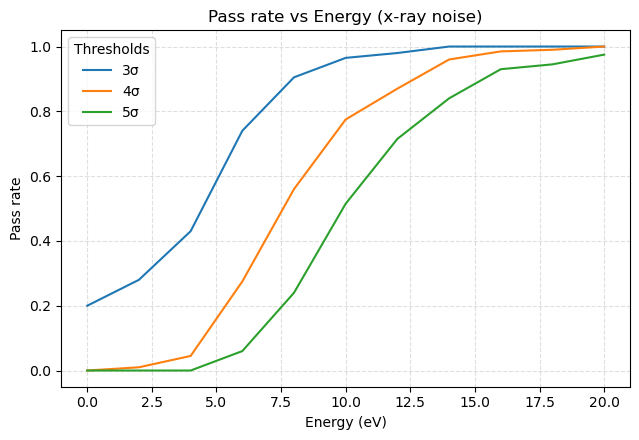


Pass rates:
Energy           3σ          4σ          5σ
0            0.2000     0.0000     0.0000
2            0.2800     0.0100     0.0000
4            0.4300     0.0450     0.0000
6            0.7400     0.2750     0.0600
8            0.9050     0.5600     0.2400
10           0.9650     0.7750     0.5150
12           0.9800     0.8700     0.7150
14           1.0000     0.9600     0.8400
16           1.0000     0.9850     0.9300
18           1.0000     0.9900     0.9450
20           1.0000     1.0000     0.9750


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
base_dir = Path("/ceph/dwong/work/threshold/noise_13.2/indiv_max_amp")
import re
from pathlib import Path

thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = list(np.arange(0, 22, 2, dtype=int))
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate")
plt.title("Pass rate vs Energy (x-ray noise)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


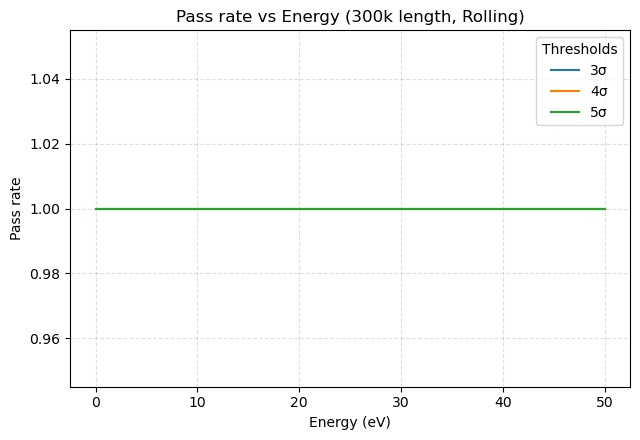


Pass rates:
Energy           3σ          4σ          5σ
0            1.0000     1.0000     1.0000
5            1.0000     1.0000     1.0000
10           1.0000     1.0000     1.0000
15           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000
25           1.0000     1.0000     1.0000
30           1.0000     1.0000     1.0000
35           1.0000     1.0000     1.0000
40           1.0000     1.0000     1.0000
45           1.0000     1.0000     1.0000
50           1.0000     1.0000     1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
base_dir = Path("/ceph/dwong/trigger_samples/TD_noise/amplitudes")
import re
from pathlib import Path

thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate")
plt.title("Pass rate vs Energy (300k length, Rolling)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


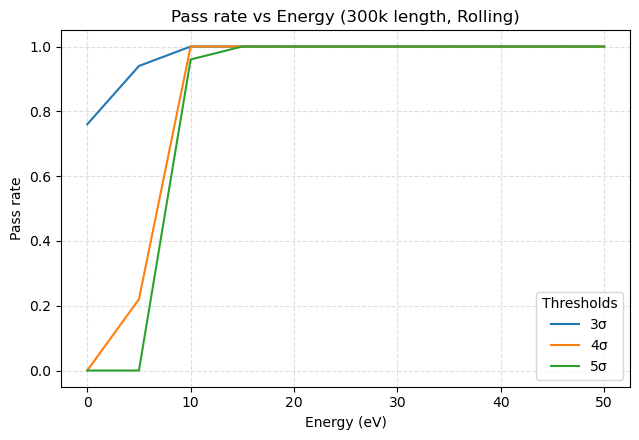


Pass rates:
Energy           3σ          4σ          5σ
0            0.7600     0.0000     0.0000
5            0.9400     0.2200     0.0000
10           1.0000     1.0000     0.9600
15           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000
25           1.0000     1.0000     1.0000
30           1.0000     1.0000     1.0000
35           1.0000     1.0000     1.0000
40           1.0000     1.0000     1.0000
45           1.0000     1.0000     1.0000
50           1.0000     1.0000     1.0000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
base_dir = Path("/ceph/dwong/trigger_samples/Johnson_noise/amplitudes")
import re
from pathlib import Path

thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate")
plt.title("Pass rate vs Energy (300k length, Rolling)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


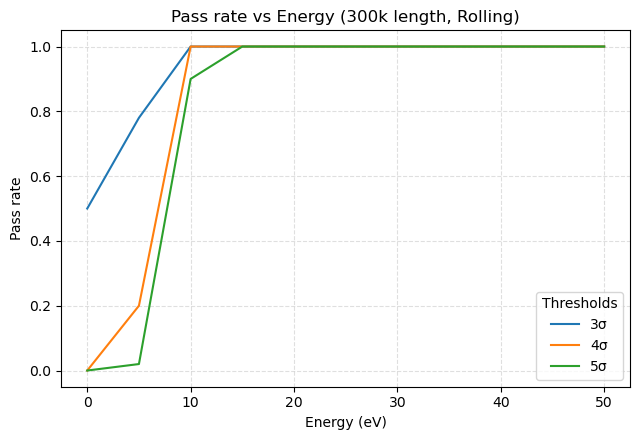


Pass rates:
Energy           3σ          4σ          5σ
0            0.5000     0.0000     0.0000
5            0.7800     0.2000     0.0200
10           1.0000     1.0000     0.9000
15           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000
25           1.0000     1.0000     1.0000
30           1.0000     1.0000     1.0000
35           1.0000     1.0000     1.0000
40           1.0000     1.0000     1.0000
45           1.0000     1.0000     1.0000
50           1.0000     1.0000     1.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
base_dir = Path("/ceph/dwong/trigger_samples/SQUID_noise/amplitudes")
import re
from pathlib import Path

thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate")
plt.title("Pass rate vs Energy (300k length, Rolling)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


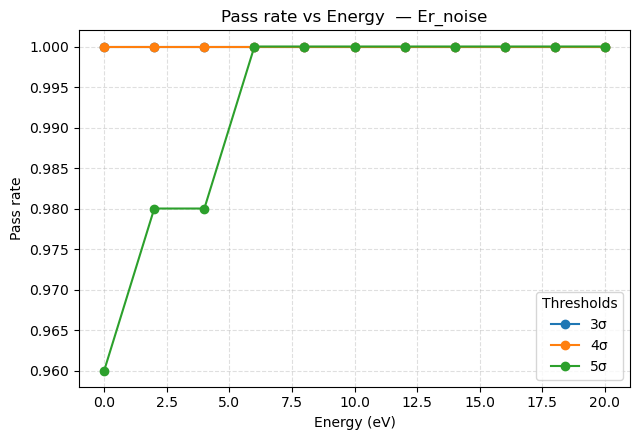


Pass rates table — Er_noise
Energy           3σ          4σ          5σ
0            1.0000     1.0000     0.9600
2            1.0000     1.0000     0.9800
4            1.0000     1.0000     0.9800
6            1.0000     1.0000     1.0000
8            1.0000     1.0000     1.0000
10           1.0000     1.0000     1.0000
12           1.0000     1.0000     1.0000
14           1.0000     1.0000     1.0000
16           1.0000     1.0000     1.0000
18           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000


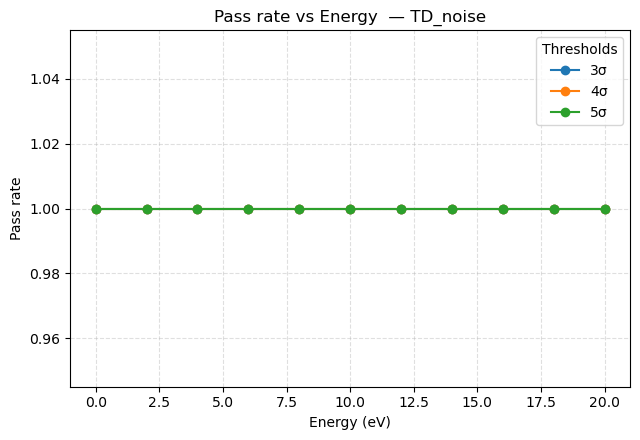


Pass rates table — TD_noise
Energy           3σ          4σ          5σ
0            1.0000     1.0000     1.0000
2            1.0000     1.0000     1.0000
4            1.0000     1.0000     1.0000
6            1.0000     1.0000     1.0000
8            1.0000     1.0000     1.0000
10           1.0000     1.0000     1.0000
12           1.0000     1.0000     1.0000
14           1.0000     1.0000     1.0000
16           1.0000     1.0000     1.0000
18           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000


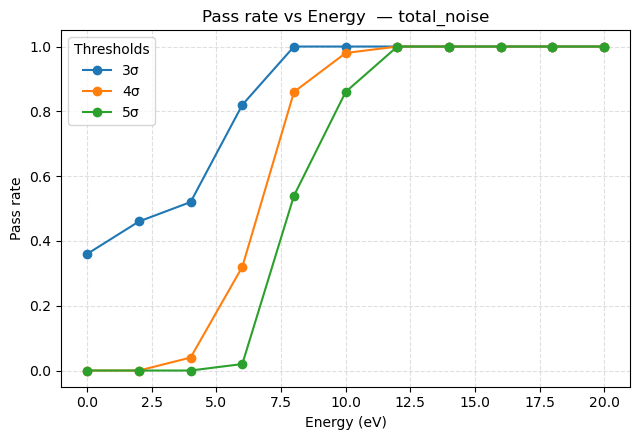


Pass rates table — total_noise
Energy           3σ          4σ          5σ
0            0.3600     0.0000     0.0000
2            0.4600     0.0000     0.0000
4            0.5200     0.0400     0.0000
6            0.8200     0.3200     0.0200
8            1.0000     0.8600     0.5400
10           1.0000     0.9800     0.8600
12           1.0000     1.0000     1.0000
14           1.0000     1.0000     1.0000
16           1.0000     1.0000     1.0000
18           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000


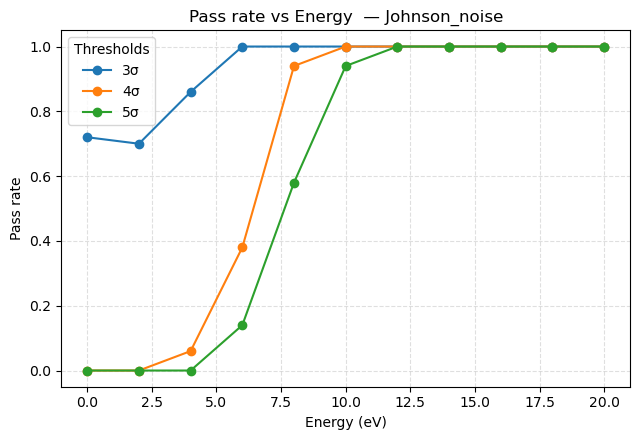


Pass rates table — Johnson_noise
Energy           3σ          4σ          5σ
0            0.7200     0.0000     0.0000
2            0.7000     0.0000     0.0000
4            0.8600     0.0600     0.0000
6            1.0000     0.3800     0.1400
8            1.0000     0.9400     0.5800
10           1.0000     1.0000     0.9400
12           1.0000     1.0000     1.0000
14           1.0000     1.0000     1.0000
16           1.0000     1.0000     1.0000
18           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000


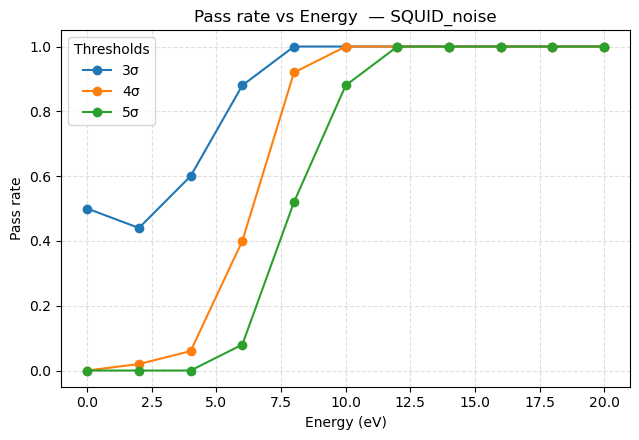


Pass rates table — SQUID_noise
Energy           3σ          4σ          5σ
0            0.5000     0.0000     0.0000
2            0.4400     0.0200     0.0000
4            0.6000     0.0600     0.0000
6            0.8800     0.4000     0.0800
8            1.0000     0.9200     0.5200
10           1.0000     1.0000     0.8800
12           1.0000     1.0000     1.0000
14           1.0000     1.0000     1.0000
16           1.0000     1.0000     1.0000
18           1.0000     1.0000     1.0000
20           1.0000     1.0000     1.0000


In [3]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Settings
# -------------------------------
ROOT = Path("/ceph/dwong/trigger_samples")
NOISESETS = [
    "Er_noise",
    "TD_noise",
    "total_noise",
    "Johnson_noise",
    "SQUID_noise",
]
SUBDIR = "amplitudes"
FILE_TMPL = "max_amplitudes_energy_{E}.npy"

# Energies: step of 2 eV from 0 to 21 (will check file existence per noise)
ENERGIES = list(np.arange(0, 22, 2, dtype=int))  # 0,2,4,...,20

# Thresholds & labels
THRESHOLDS = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
LABELS = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}

# Plot style
PLOT_TITLE_SUFFIX = "Pass rate vs Energy "


# -------------------------------
# Helpers
# -------------------------------
def compute_pass_rates(base_dir: Path, energies, thresholds):
    """Return available_E list and dict of pass_rates[thr] -> list aligned with available_E."""
    pass_rates = {thr: [] for thr in thresholds}
    available_E = []

    for E in energies:
        path = (base_dir / FILE_TMPL.format(E=E))
        if not path.exists():
            print(f"[warn] Missing file, skipping: {path}")
            continue

        data = np.load(path)  # expected shape (repeats=100, n_traces=56)
        if data.ndim != 2 or data.shape[1] != 56:
            raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

        available_E.append(E)

        # event passes if any channel in that repeat >= threshold
        for thr in thresholds:
            passes = (data >= thr).any(axis=1)  # boolean length R
            pass_rate = passes.mean()           # fraction in [0, 1]
            pass_rates[thr].append(pass_rate)

    return available_E, pass_rates


def plot_pass_rates(available_E, pass_rates, noise_name):
    plt.figure(figsize=(6.5, 4.5))
    for thr in THRESHOLDS:
        if len(pass_rates[thr]) > 0:
            plt.plot(available_E, pass_rates[thr], marker="o", label=LABELS[thr])

    plt.xlabel("Energy (eV)")
    plt.ylabel("Pass rate")
    plt.title(f"{PLOT_TITLE_SUFFIX} — {noise_name}")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend(title="Thresholds")
    plt.tight_layout()
    plt.show()


def print_table(available_E, pass_rates, noise_name):
    print(f"\nPass rates table — {noise_name}")
    header = "Energy".ljust(8) + " " + "  ".join([f"{LABELS[thr]:>10}" for thr in THRESHOLDS])
    print(header)
    for i, E in enumerate(available_E):
        row = [f"{E:<8}"]
        for thr in THRESHOLDS:
            row.append(f"{pass_rates[thr][i]:>10.4f}")
        print(" ".join(row))


# -------------------------------
# Main
# -------------------------------
def main():
    for noise_name in NOISESETS:
        base_dir = ROOT / noise_name / SUBDIR

        if not base_dir.exists():
            print(f"[warn] Base dir not found for {noise_name}: {base_dir}")
            continue

        # Option A: strictly follow the 0:2:21 grid, skipping missing files.
        available_E, pass_rates = compute_pass_rates(base_dir, ENERGIES, THRESHOLDS)

        # If none available on that grid, optionally fall back to autodetect:
        if len(available_E) == 0:
            print(f"[info] No files on 0–20 step-2 grid for {noise_name}. Trying autodetect...")
            autodetect = sorted(
                int(re.search(r"energy_(\d+)", f.name).group(1))
                for f in base_dir.glob("max_amplitudes_energy_*.npy")
                if re.search(r"energy_(\d+)", f.name)
            )
            available_E, pass_rates = compute_pass_rates(base_dir, autodetect, THRESHOLDS)

        if len(available_E) == 0:
            print(f"[warn] No data found for {noise_name}. Skipping plot and table.")
            continue

        plot_pass_rates(available_E, pass_rates, noise_name)
        print_table(available_E, pass_rates, noise_name)


if __name__ == "__main__":
    main()
